## Data Loading

In [270]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Read the data
train_data = pd.read_csv('/kaggle/input/home-data-for-ml-course/train.csv', index_col="Id")
test_data = pd.read_csv('/kaggle/input/home-data-for-ml-course/test.csv', index_col = 'Id')
print(f'The size of train data{train_data.shape} , the size of test data{test_data.shape}' )


The size of train data(1460, 80) , the size of test data(1459, 79)


## Data Preprocessing

I will impute these values later.

In [271]:
print(f'Missing values in train set:{train_data.isnull().sum().sum()} and test set {test_data.isnull().sum().sum()}')

Missing values in train set:7829 and test set 7878


In [272]:
nr_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
corrs = X_train[nr_cols].corrwith(train_data['SalePrice'])
corrs




MSSubClass      -0.083961
LotFrontage      0.382742
LotArea          0.266213
OverallQual      0.786470
OverallCond     -0.061666
YearBuilt        0.511874
YearRemodAdd     0.495893
MasVnrArea       0.470014
BsmtFinSF1       0.412857
BsmtFinSF2      -0.011001
BsmtUnfSF        0.205026
TotalBsmtSF      0.649579
1stFlrSF         0.637294
2ndFlrSF         0.318564
LowQualFinSF    -0.021818
GrLivArea        0.736125
BsmtFullBath     0.223701
BsmtHalfBath    -0.009636
FullBath         0.569521
HalfBath         0.259671
BedroomAbvGr     0.178483
KitchenAbvGr    -0.128401
TotRmsAbvGrd     0.527113
Fireplaces       0.470761
GarageYrBlt      0.484033
GarageCars       0.651061
GarageArea       0.649904
WoodDeckSF       0.313716
OpenPorchSF      0.315348
EnclosedPorch   -0.140534
3SsnPorch        0.058209
ScreenPorch      0.132530
PoolArea         0.110250
MiscVal         -0.014572
MoSold           0.050988
YrSold          -0.044989
dtype: float64

I will focus on the features that show a correlation above 0.6 with the target

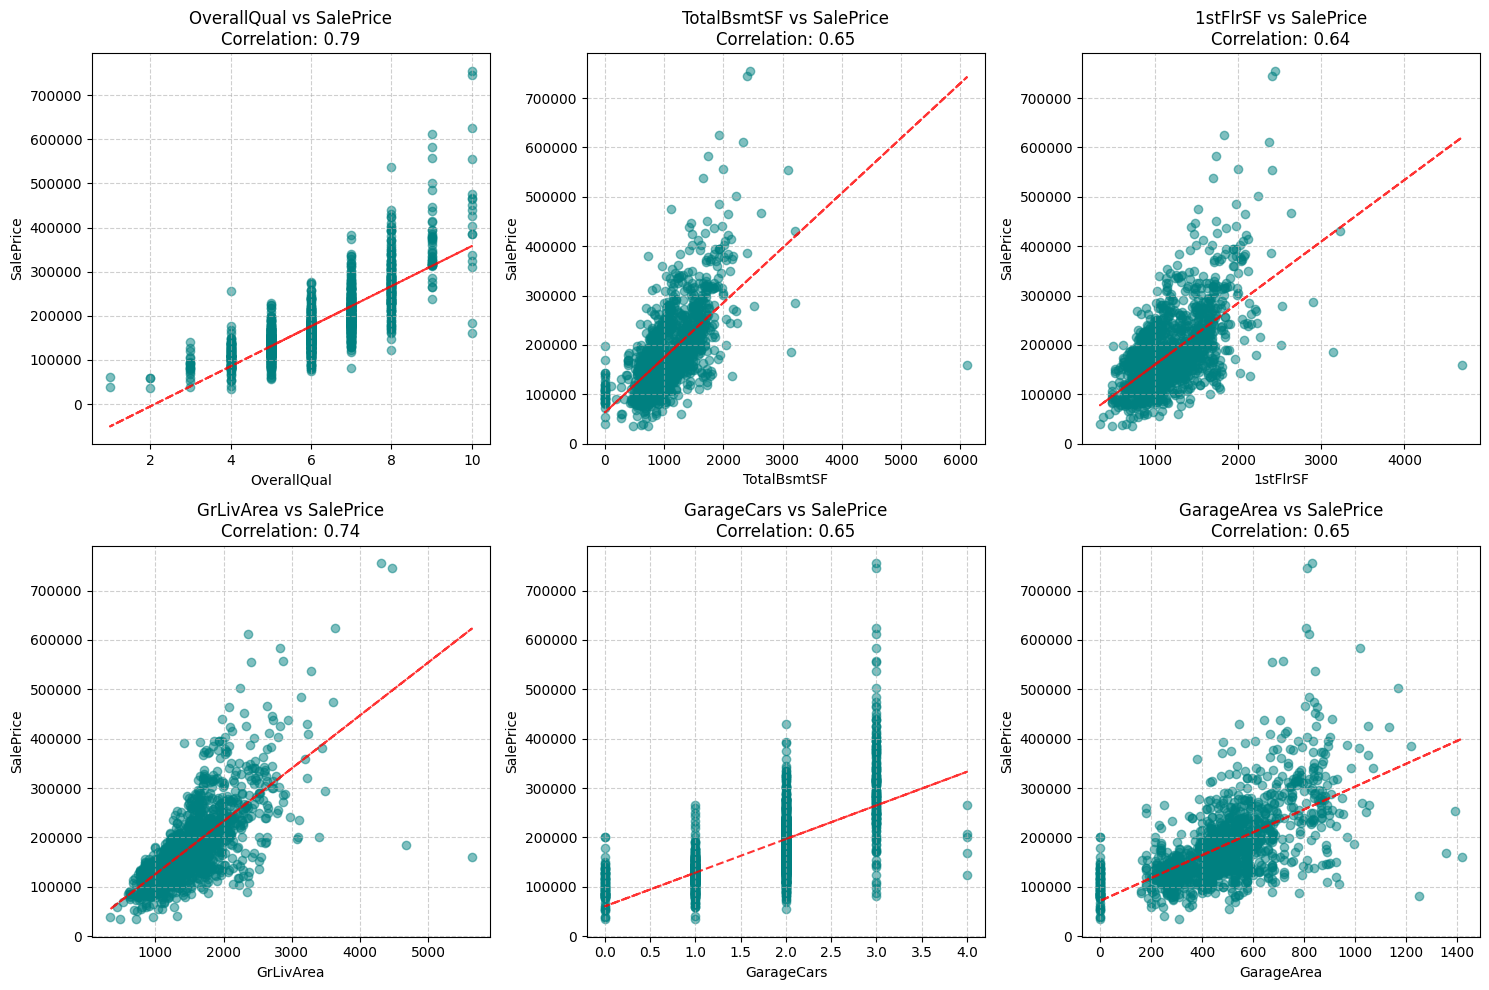

Features with a correlation above 0.6 are : ['OverallQual', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'GarageCars', 'GarageArea']


In [273]:
high_corr_features = corrs[corrs > 0.6].index.tolist()
if 'SalePrice' in high_corr_features:
    high_corr_features.remove('SalePrice')


# Determine how many rows and columns we need.
n_features = len(high_corr_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 5))

for i, col in enumerate(high_corr_features):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Scatter plot
    plt.scatter(train_data[col], train_data['SalePrice'], alpha=0.5, color='teal')
    
    # I will add a trendline in the chart
    z = np.polyfit(train_data[col], train_data['SalePrice'], 1)
    p = np.poly1d(z)
    plt.plot(train_data[col], p(train_data[col]), "r--", alpha=0.8)
    
    plt.title(f"{col} vs SalePrice\nCorrelation: {corrs[col]:.2f}")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Features with a correlation above 0.6 are : {high_corr_features}")

We have a few outliers in the 'GarageArea vs SalePrice', 'TotalBsmtSF vs SalePrice', '1stFlrSF vs SalePrice' and 'GrLivArea vs SalePrice' plots that could cause problems later on.

In [274]:
train_data = train_data.drop(train_data[(train_data['GrLivArea'] > 4000) 
                             & (train_data['SalePrice'] < 300_000)].index)
train_data = train_data.drop(train_data[(train_data['GarageArea'] > 1200) 
                             & (train_data['SalePrice'] < 300_000)].index)
train_data = train_data.drop(train_data[(train_data['TotalBsmtSF'] > 4000) 
                             & (train_data['SalePrice'] < 300_000)].index)
train_data = train_data.drop(train_data[(train_data['1stFlrSF'] > 4000) 
                             & (train_data['SalePrice'] < 300_000)].index)

print(f'The size of train data{train_data.shape} , the size of test data{test_data.shape}' )

The size of train data(1455, 80) , the size of test data(1459, 79)


## Training and Evaluation

In [275]:
#Remove rows with missing target
train_data.dropna(axis=0, subset='SalePrice', inplace=True)
y = train_data['SalePrice']
train_data.drop(['SalePrice'], axis = 1 , inplace = True)
# Break off valitation set from training set
X_train_full, X_valid_full, y_train, y_valid =  train_test_split(train_data, y,
                                                                 train_size= 0.8, test_size = 0.2,
                                                                random_state=0)
low_cardinality_cols = [col for col in X_train_full.columns 
                        if X_train_full[col].nunique() <10 and
                       X_train_full[col].dtype == 'object']

numeric_cols = [col for col in X_train_full.columns 
                if X_train_full[col].dtype in ['int64','float64']]
print( low_cardinality_cols)
print(numeric_cols)

#
valid_cols = low_cardinality_cols + numeric_cols
X_train = X_train_full[valid_cols].copy()
X_valid = X_valid_full[valid_cols].copy()
X_test = test_data[valid_cols].copy()
print("\n")
print(f'The size of train data{X_train.shape} , the size of test data{y.shape}' )

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolAre

In [276]:
# Break off the columns for ordinal encoding from all categorical columns.
categorical_cols_ordinal= ['HeatingQC','PoolQC','GarageQual','GarageCond','FireplaceQu', 'KitchenQual','BsmtCond','BsmtQual','ExterQual']
categorical_cols_one_hot = [col for col in low_cardinality_cols if col  not in categorical_cols_ordinal ]
print(categorical_cols_ordinal)
print()
print(categorical_cols_one_hot)

['HeatingQC', 'PoolQC', 'GarageQual', 'GarageCond', 'FireplaceQu', 'KitchenQual', 'BsmtCond', 'BsmtQual', 'ExterQual']

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


Here I will handle the missing values automatically using the SimpleImputer function from sklearn. I will also define a pipeline that will automatically perform imputation, encoding, and model construction.

In [277]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error


# Define the pipeline 
one_hot_encoding = Pipeline(steps =[
    ('imputer' , SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown ='ignore', sparse_output = False))
])
ordinal_encoding = Pipeline(steps=[
    ('imputer',  SimpleImputer(strategy = 'most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])
numarical = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy = 'mean') ),
  #  ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numarical , numeric_cols),
        ('cat_onehot', one_hot_encoding, categorical_cols_one_hot ), #low_cardinality_cols
        ('cat_ordinal', ordinal_encoding, categorical_cols_ordinal )
    ])
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators = 300, random_state=42))
    #('model', XGBRegressor(n_estimators=n_estimators,learning_rate=learning_rate, random_state=0))
])

my_pipeline.fit(X_train, y_train)

y_pred = my_pipeline.predict(X_valid)

score = mean_absolute_error(y_pred, y_valid)
print(f"MAE: {score}")


MAE: 17568.95137457045


### Cross Validation 

In [278]:
from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates *negative* MAE
scores = -1 * cross_val_score(my_pipeline, train_data[valid_cols], y,
                              cv=5,
                              scoring='neg_mean_absolute_error')

print("MAE for each CV fold:", scores)
print("Average MAE:", scores.mean())

MAE for each CV fold: [17540.42775487 15709.46956472 17377.9962543  16223.28778923
 17829.38912944]
Average MAE: 16936.11409851088


### Evaluation of Random Forest performance for different numbers of trees using a full preprocessing  pipeline

In [279]:
def get_score_rf(n_estimators ):
    my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators = n_estimators, random_state=42))
    ])
    my_pipeline.fit(X_train, y_train)

    y_pred = my_pipeline.predict(X_valid)
    
    score = mean_absolute_error(y_pred, y_valid)
    return score

scores = {estimators: get_score_rf(estimators) for estimators in range (100, 701,50) }
print(scores)
print(f'Using {min(scores, key=scores.get )} estimators, the MAE reached its best value:{scores[min(scores, key=scores.get )]}')

{100: 17600.451615120273, 150: 17662.63214203895, 200: 17637.59735395189, 250: 17613.296164948453, 300: 17568.95137457045, 350: 17481.48975945017, 400: 17453.279845360827, 450: 17335.116197021765, 500: 17347.47745017182, 550: 17296.189478288034, 600: 17312.853327605957, 650: 17334.53652656622, 700: 17339.960540009815}
Using 550 estimators, the MAE reached its best value:17296.189478288034


### Evaluation of XGBoost performance for different numbers of trees using a full preprocessing and feature selection pipeline

In [280]:
def get_score_xgb(n_estimators  ,learning_rate):
    my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, random_state=0))
    ])
    my_pipeline.fit(X_train, y_train)

    y_pred = my_pipeline.predict(X_valid)
    
    score = mean_absolute_error(y_pred, y_valid)
    return score

scores = {estimators: get_score_xgb(estimators, learning_rate=0.1) for estimators in range (500, 2001,100) }
print(scores)
print()
print(f'Using {min(scores, key=scores.get )} estimators, the MAE reached its best value:{scores[min(scores, key=scores.get )]}')

{500: 16629.919921875, 600: 16626.0, 700: 16623.828125, 800: 16623.556640625, 900: 16623.99609375, 1000: 16624.5703125, 1100: 16624.642578125, 1200: 16624.556640625, 1300: 16624.365234375, 1400: 16624.470703125, 1500: 16624.525390625, 1600: 16624.564453125, 1700: 16624.578125, 1800: 16624.583984375, 1900: 16624.587890625, 2000: 16624.587890625}

Using 800 estimators, the MAE reached its best value:16623.556640625


### Feature Selection

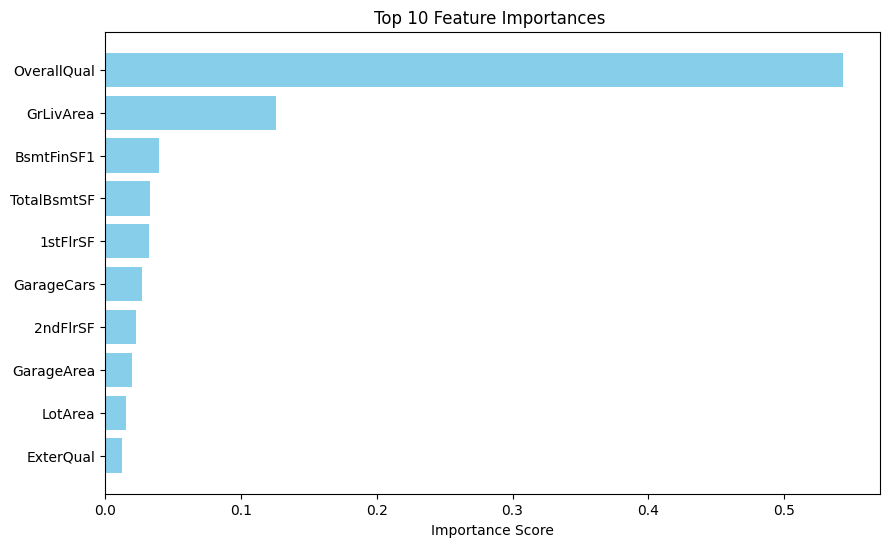

        Feature  Importance
0   OverallQual    0.543148
1     GrLivArea    0.125967
2    BsmtFinSF1    0.040070
3   TotalBsmtSF    0.033433
4      1stFlrSF    0.032729
5    GarageCars    0.027611
6      2ndFlrSF    0.023083
7    GarageArea    0.019869
8       LotArea    0.015323
9     ExterQual    0.012830
10    YearBuilt    0.009596
11   MasVnrArea    0.006576
12     FullBath    0.006458
13  LotFrontage    0.005618
14    BsmtUnfSF    0.005584


In [281]:
import matplotlib.pyplot as plt

num_names = numeric_cols

# Get feature names created by One-Hot Encoding
ohe_names = list(
    my_pipeline.named_steps['preprocessor']
    .named_transformers_['cat_onehot']
    .named_steps['onehot']
    .get_feature_names_out(categorical_cols_one_hot)
)

# Ordinal columns keep the same names
ord_names = categorical_cols_ordinal

# Full feature list in model input order
all_feature_names = num_names + ohe_names + ord_names

# Extract feature importances from the model
importances = my_pipeline.named_steps['model'].feature_importances_

# Create a sorted DataFrame with feature importances
feat_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'][:10],
         feat_importance['Importance'][:10],
         color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances ')
plt.xlabel('Importance Score')
plt.show()

print(feat_importance.head(15))


From this chart, we can observe that most features have a very small contribution to the model’s decision‑making process. After applying feature selection, the model becomes structurally simpler, requires fewer computations, reduces the risk of overfitting, and focuses only on the most informative variables, leading to better generalization performance.

In [282]:
def add_features(X):
    X_copy = X.copy()
    X_copy['TotalSF'] = X_copy['1stFlrSF'] + X_copy['2ndFlrSF'] + X_copy['TotalBsmtSF'] 
    X_copy['HouseAge'] = X_copy['YrSold'] - X_copy['YearBuilt']
    X_copy['TotalBath'] = X_copy['FullBath'] + (0.5 * X_copy['HalfBath']) + X_copy['BsmtFullBath']
    return X_copy
numeric_cols_extended = numeric_cols + ['TotalSF', 'HouseAge', 'TotalBath']

In [283]:
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import FunctionTransformer
selector = SelectFromModel(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    threshold=0.001
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numarical, numeric_cols_extended), 
        ('cat_onehot', one_hot_encoding, categorical_cols_one_hot),
        ('cat_ordinal', ordinal_encoding, categorical_cols_ordinal)
    ])
my_pipeline = Pipeline(steps=[
    ('feature_eng', FunctionTransformer(add_features)),
    ('preprocessor', preprocessor),
    ('feature_selection', selector), 
    ('model', RandomForestRegressor(n_estimators=200, random_state=42)) # MAE: 17121.5369   , 16343.7798
    #('model', XGBRegressor(n_estimators=750, learning_rate=0.01, random_state=42)) #MAE: 17169.8359375

   
])

my_pipeline.fit(X_train, y_train)

y_pred = my_pipeline.predict(X_valid)

score = mean_absolute_error(y_pred, y_valid)
print(f"MAE: {score}")

    

MAE: 16343.779845360827


### Cross Validation 

In [284]:
from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates *negative* MAE
scores = -1 * cross_val_score(my_pipeline, train_data[valid_cols], y,
                              cv=5,
                              scoring='neg_mean_absolute_error')

print("MAE for each CV fold:", scores)
print("Average MAE:", scores.mean())

MAE for each CV fold: [17563.77730241 16561.82840206 16859.69467354 15214.04142039
 17268.0717354 ]
Average MAE: 16693.482706758303


The fact that the error on a single validation set (16343.77) is very close to the Cross‑Validation average (16693.42) is a good sign.

### Evaluation of Random Forest performance for different numbers of trees using a full preprocessing and feature selection pipeline

In [285]:
def get_score_rf(n_estimators ):
    my_pipeline = Pipeline(steps=[
    ('feature_eng', FunctionTransformer(add_features)),
    ('preprocessor', preprocessor),
    ('feature_selection', selector),
    ('model', RandomForestRegressor(n_estimators = n_estimators, random_state=42))
    ])
    my_pipeline.fit(X_train, y_train)

    y_pred = my_pipeline.predict(X_valid)
    
    score = mean_absolute_error(y_pred, y_valid)
    return score

scores = {estimators: get_score_rf(estimators) for estimators in range (100, 701,50) }
print(scores)
print(f'Using {min(scores, key=scores.get )} estimators, the MAE reached its best value:{scores[min(scores, key=scores.get )]}')

{100: 16424.654604810996, 150: 16358.29706758305, 200: 16343.779845360827, 250: 16342.752591065291, 300: 16367.385315005728, 350: 16325.129199803634, 400: 16311.651709621992, 450: 16283.01267659412, 500: 16249.185154639175, 550: 16266.823199000311, 600: 16268.022073310422, 650: 16281.57066878139, 700: 16253.204030436915}
Using 500 estimators, the MAE reached its best value:16249.185154639175


### Evaluation of XGBoost performance for different numbers of trees using a full preprocessing and feature selection pipeline

In [286]:
def get_score_xgb(n_estimators  ,learning_rate):
    my_pipeline = Pipeline(steps=[
    ('feature_eng', FunctionTransformer(add_features)),
    ('preprocessor', preprocessor),
    ('feature_selection', selector),
    ('model', XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, random_state=0))
    ])
    my_pipeline.fit(X_train, y_train)

    y_pred = my_pipeline.predict(X_valid)
    
    score = mean_absolute_error(y_pred, y_valid)
    return score

scores = {estimators: get_score_xgb(estimators, learning_rate=0.01) for estimators in range (500, 2001,100) }
print(scores)
print()
print(f'Using {min(scores, key=scores.get )} estimators, the MAE reached its best value:{scores[min(scores, key=scores.get )]}')

{500: 15846.1240234375, 600: 15807.6220703125, 700: 15755.345703125, 800: 15745.4189453125, 900: 15739.8037109375, 1000: 15746.353515625, 1100: 15767.4296875, 1200: 15778.359375, 1300: 15793.5546875, 1400: 15819.99609375, 1500: 15830.7109375, 1600: 15849.5048828125, 1700: 15851.41796875, 1800: 15856.486328125, 1900: 15850.5185546875, 2000: 15873.224609375}

Using 900 estimators, the MAE reached its best value:15739.8037109375


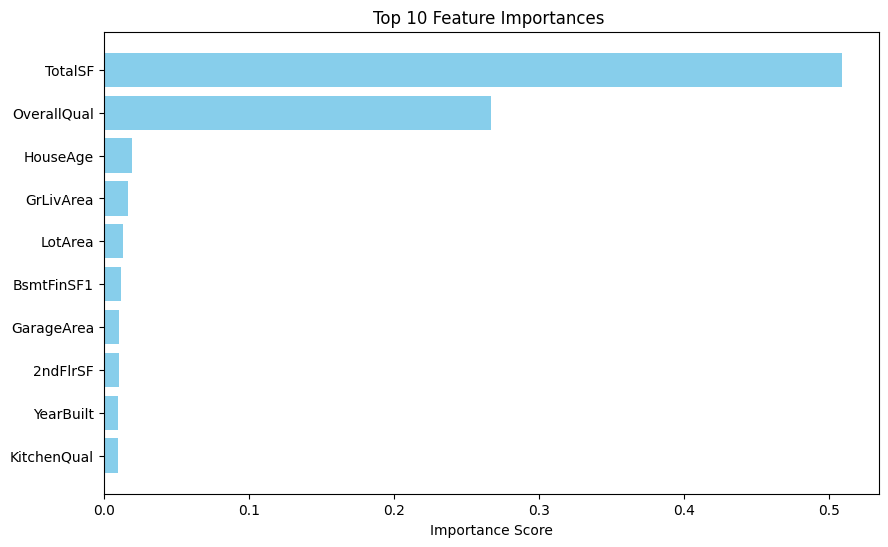

             Feature  Importance
0            TotalSF    0.509136
1        OverallQual    0.266895
2           HouseAge    0.019192
3          GrLivArea    0.016538
4            LotArea    0.013540
5         BsmtFinSF1    0.012109
6         GarageArea    0.010681
7           2ndFlrSF    0.010623
8          YearBuilt    0.010071
9        KitchenQual    0.009876
10      YearRemodAdd    0.009863
11         ExterQual    0.009179
12         BsmtUnfSF    0.008753
13       OverallCond    0.008524
14          BsmtQual    0.008371
15         TotalBath    0.007667
16        GarageCars    0.007347
17       LotFrontage    0.006896
18       GarageYrBlt    0.005782
19          1stFlrSF    0.005077
20       TotalBsmtSF    0.004553
21       OpenPorchSF    0.004277
22        WoodDeckSF    0.003949
23            MoSold    0.003923
24        Fireplaces    0.003647
25        MasVnrArea    0.003289
26      TotRmsAbvGrd    0.002545
27      CentralAir_Y    0.002119
28        MSSubClass    0.002024
29        

In [287]:
# 1. Retrieve all feature names after preprocessing (as before)
num_names = numeric_cols_extended
ohe_names = list(my_pipeline.named_steps['preprocessor']
                 .named_transformers_['cat_onehot']
                 .named_steps['onehot']
                 .get_feature_names_out(categorical_cols_one_hot))
ord_names = categorical_cols_ordinal
all_feature_names_before_selection = num_names + ohe_names + ord_names

# 2. FIND WHICH FEATURES WERE SELECTED BY 'SelectFromModel'
# get_support() returns a True/False mask for each feature
selector = my_pipeline.named_steps['feature_selection']
selected_mask = selector.get_support()

# Filter feature names using the selector mask
final_feature_names = [
    name for name, selected in zip(all_feature_names_before_selection, selected_mask)
    if selected
]

# 3. Extract feature importances from the final model
importances = my_pipeline.named_steps['model'].feature_importances_

# 4. Now the lengths match! Create the DataFrame
feat_importance = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'][:10],
         feat_importance['Importance'][:10],
         color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances ')
plt.xlabel('Importance Score')
plt.show()

#print(f"Selectorul a păstrat {len(final_feature_names)} coloane din {len(all_feature_names_before_selection)}")
print(feat_importance)


From the chart, we can see that the engineered features played an important role in the model’s decisions.

## Insights

### In the context of this dataset, where house prices can reach several hundred thousand dollars, an error of around 16,000 is a fairly solid result. For example, if a house costs 180,000, the model would miss the prediction by roughly 8.8% (16,000/180,000). In the real‑estate domain, such an error is acceptable, since a home’s price often depends on subjective factors, such as negotiation.